In [ ]:
# imports
import os
import random
import re
from datetime import timedelta
from glob import glob

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from keras.utils import to_categorical
from matplotlib.ticker import FuncFormatter
from numpy.random import default_rng
from sklearn.model_selection import KFold
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    auc,
    precision_recall_curve,
    average_precision_score,
)

import data_models
import data_preprocessing
import Code.data_integration_v1 as data_integration_v1
from data_integration import combine_data, read_data

In [3]:
# convert all sublists to arrays
def flatten(subject):
    array_data = [np.array(x) for x in subject]  
    flattened_data = np.concatenate(array_data, axis=0)
    return flattened_data

## Read the dataset

In [ ]:
"""
    Calls the "read_data()" function from file "data_integration.py"
    Calls the "combine_data()" function from file "data_integration.py"
    Parameter:
    - 1: combines only glucose data
    - 2: combines glucose and dempgraphics
    - 3: combines glucose and heartrate
    Output: This function returns the intrgrated dataset included the restricted databases if downloaded and added to folder "datasets for T1D"
 """
# reads all datasets, if they are stored in the required folder DiaData/datasets for T1D/...
restricted_list = data_integration_v1.read_data(read_all = False)

In [ ]:
# loads the main dataset including 13 datasets with CGM measurements only if downloaded from OpenHSU
combined_main_list = pl.read_csv("DiaData/datasets for T1D/main_full.csv")
combined_main_list = combined_main_list.sort(["PtID", "ts"])
combined_main_list = combined_main_list.to_pandas()
# converts the timestamp column to datetime
combined_main_list["ts"] = pd.to_datetime(combined_main_list["ts"])

# integrates the restricted datasets with modus = 1
combined_main = combine_data(1, restricted_list)  
# combines both dataframes to have the final integrated dataset 
combined_main = pd.concat([combined_main, combined_main_list])
# saves the full integrated main dataset as a csv file
#combined_main.to_csv("datasets for T1D/fullmaindatabase.csv", index=False)

## Assign classes and generate time series

In [9]:
# dataset with interpolated values is copied
classes_df = combined_main.copy()
# initially all classes are assigned class -1
classes_df["Class"] = -1
# hypoglycemic values are defined as class 0 with values equal and lower than 70 mg/dL
classes_df.loc[classes_df["GlucoseCGM"] <= 70, "Class"] = 0

# calls the function class_generation to assing classes based on wanted intervals before hypogylcemia for each subject separately
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 5, 15, 1)) # 5-15 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 15, 30, 2)) # 15-30 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts", 30, 60, 3))  # 30-60 min
classes_df = classes_df.groupby("PtID", group_keys=False).apply(lambda x: data_preprocessing.class_generation(x,"ts",  60, 125, 4)) # 1-2 h
classes_df.loc[classes_df["Class"] == -1, "Class"] = 5

# sorts the glucose values by patient id and timestamps
df_sorted = classes_df.sort_values(by=['PtID', 'ts'])
# reindexes based on the sorted dataset
df_sorted = df_sorted.reset_index(drop=True)

In [ ]:
# prints the distribution of classes
df_sorted["Class"].value_counts()

Class
5    218757421
4      6468276
0      6195639
3      3287930
2      1785862
1      1431139
Name: count, dtype: int64

## Normalization

In [11]:
# normalizes data 
df_min_max_scaled = data_preprocessing.normalize_data(df_sorted, 'GlucoseCGM')

## Generate time series sequences

In [12]:
def create_X_Y(df, feature, sample_count= 25, hours = 2, modus = 'h'):

    # generates time series with sliding window approach
    result = df.groupby('PtID').apply(lambda g: data_preprocessing.extract_valid_windows_GLC(g, expected_sample_count = sample_count,
    min_window_duration = np.timedelta64(hours, modus)))

    # filters out None values of subjects with insufficient data
    filtered_result = [item for item in result if item is not None]
    # unpacks the values
    X_data, Y_data = zip(*filtered_result)

    return X_data, Y_data

# calls the function for time series generation with a 30 min input length 
X_data, Y_data = create_X_Y(df_min_max_scaled, "PtID", 7, 30, 'm')

## FCN model

In [13]:
# ensures reproducability
seed_value= 42  
os.environ["PYTHONHASHSEED"]=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)

# initializes 5 folds
kfolds = KFold(n_splits=5, shuffle=True, random_state=42)
with open("RMDB_5fold_indices.txt", "w", encoding="utf-8") as f:
    for fold, (train_idx, test_idx) in enumerate(kfolds.split(X_data), start=1):
        f.write(f"Fold {fold}\n")
        f.write("Train indices:\n")
        f.write(" ".join(map(str, train_idx)) + "\n")
        f.write("Test indices:\n")
        f.write(" ".join(map(str, test_idx)) + "\n")
        f.write("\n")

Started for fold 1


2025-09-25 21:40:50.162505: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-09-25 21:40:50.162526: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-09-25 21:40:52.055485: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


   26/91460 [..............................] - ETA: 3:08   

2025-09-26 01:20:53.869732: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


91460/91460 [==============================] - 153s 2ms/step


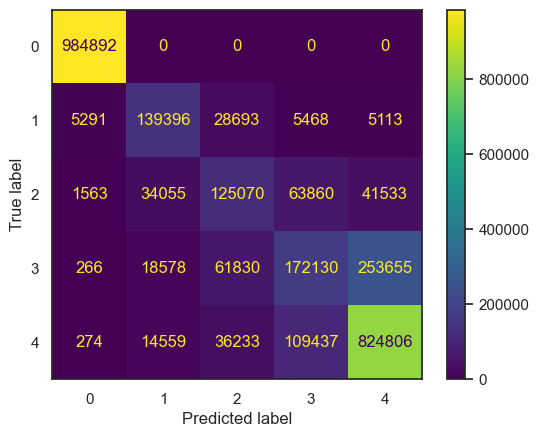

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


              precision    recall  f1-score   support

           0     0.9925    1.0000    0.9963    984892
           1     0.6748    0.7577    0.7138    183961
           2     0.4967    0.4700    0.4830    266081
           3     0.4905    0.3399    0.4015    506459
           4     0.7331    0.8371    0.7817    985309

    accuracy                         0.7675   2926702
   macro avg     0.6775    0.6810    0.6753   2926702
weighted avg     0.7533    0.7675    0.7567   2926702

Saved report for 10 RMDB FCN fold 30min focal GLC 1


In [ ]:
# ensures reproducability
seed_value= 42  
os.environ['PYTHONHASHSEED']=str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.compat.v1.set_random_seed(seed_value)
session_conf = tf.compat.v1.ConfigProto(intra_op_parallelism_threads=1, inter_op_parallelism_threads=1)
sess = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)
tf.compat.v1.keras.backend.set_session(sess)


# initializes 5 folds for cross validation
kfolds = KFold(n_splits=5, shuffle=True, random_state=42)
count = 0

# empty list for the predicted and actual values
RMDB_actual_labels_All_30min_focal_GLC = []
RMDB_predicted_labels_fcn_All_30min_focal_GLC = []

# empty lists for the metrics calculated at each fold
lower_CI = []
upper_CI = []
F1_macro = []
Rec_macro = []
Pre_macro = []
PR_AUC_macro = []

F1_class = []
Rec_class = []
Pre_class = []
PR_AUC_class = []
PR_AVG_class = []
PR_AUC_Mac = []
PR_AVG_Mac = []

ECE = []
ECE_class = []

for train_idx, test_idx in kfolds.split(X_data):

        average_precisions = []
        PRauc_scores = []

        print(f"Started for fold {count}")

        train_idx = train_idx[count]
        test_idx = test_idx[count]

        # extracts the selected subjects for training for the X and Y folds
        X_train_fold = [X_data[i] for i in train_idx]
        Y_train_fold = [Y_data[i] for i in train_idx]
        # extracts the selected subjects for testing for the X and Y folds
        X_test_fold = [X_data[i] for i in test_idx]
        Y_test_fold = [Y_data[i] for i in test_idx]

        # flattens the arrays of single subjects into one array of shape (X,7,2)
        X_train_fold = data_preprocessing.flatten_data(X_train_fold, modus = "input", shape_f = 7, dim = 1)
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_train_fold = data_preprocessing.flatten_data(Y_train_fold, modus = "output", shape_f = 7, dim = 1)

        # flattens the arrays of single subjects into one array of shape (X,7,2)
        X_test_fold = data_preprocessing.flatten_data(X_test_fold, modus = "input", shape_f =7,dim = 1) 
        # flattens the arrays of single subjects into one array of shape (X,1)
        Y_test_fold = data_preprocessing.flatten_data(Y_test_fold, modus = "output",shape_f = 7, dim = 1)

        # encodes Y data to categorical, since focal loss is used
        Y_train_encoded = to_categorical(Y_train_fold)
        Y_test_encoded = to_categorical(Y_test_fold)
        

        BUFFER_SIZE = len(X_train_fold) 
        BATCH_SIZE = 256

        # reshapes Y_train, val, and test
        Y_train_rs = Y_train_fold.reshape(-1).astype('int32')
        Y_test_rs = Y_test_fold.reshape(-1).astype('int32')

        # converts train, val, and test data into tensors
        X_train_t = tf.convert_to_tensor(X_train_fold, dtype=tf.float32)
        Y_train_t = tf.convert_to_tensor(Y_train_encoded, dtype=tf.int32)

        X_test_t = tf.convert_to_tensor(X_test_fold, dtype=tf.float32)
        Y_test_t = tf.convert_to_tensor(Y_test_encoded, dtype=tf.int32)

        # shuffles train data and applies batch size 
        train_ds_t = tf.data.Dataset.from_tensor_slices((X_train_t, Y_train_t))
        train_ds = train_ds_t.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

        optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4)
        focloss = tf.keras.losses.CategoricalFocalCrossentropy()

        # builds and trains the FCN model
        model_fcn = data_models.build_FCN((X_train_fold.shape[1], X_train_fold.shape[2]), 5) 
        model_fcn.compile(loss=focloss, optimizer=optimizer, metrics=['categorical_accuracy'])
        model_fcn.fit(train_ds, epochs=25, verbose=0)

        sns.set_theme(style="white")
        # evaluates the model and plots the confusion matrix
        predictions_fcn = model_fcn.predict(X_test_t)
        y_pred_fcn = np.argmax(predictions_fcn, axis=1) 
        y_true_labels = np.argmax(Y_test_t, axis=1)
        ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
        name_img_test = "Images/Confusion_Matrices/RMDB_FCN_5FCV_30min_focal_GLC_%i.png" % (count)
        # saves the confusion matrix
        plt.savefig(name_img_test)
        plt.show()

        # saves the model 
        name_fcn = "Models/Raw_MDB/RMDB_FCN_5FCV_30min_FL_GLC_%i.hdf5" % (count)
        model_fcn.save(name_fcn)

        report_fcn = classification_report(y_true_labels, y_pred_fcn, digits=4)
        print(report_fcn)

        # calculates metrics for each fold and saves result in an array for later computation 
        mean_f1, ci_lower, ci_upper = data_models.bootstrap_macro_f1(np.array(Y_test_rs), np.array(y_pred_fcn))

        print(f"Bootstrapped Macro F1: {mean_f1:.4f}")
        print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

        lower_CI.append(ci_lower) 
        upper_CI.append(ci_upper)

        f1_score_mac = f1_score(Y_test_rs, y_pred_fcn, average='macro')
        F1_macro.append(f1_score_mac)

        rec_scores_mac = recall_score(Y_test_rs, y_pred_fcn, average='macro')
        Rec_macro.append(rec_scores_mac)

        pre_scores_mac = precision_score(Y_test_rs, y_pred_fcn, average='macro')
        Pre_macro.append(pre_scores_mac)

        f1_scores = f1_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(5))
        F1_class.append(f1_scores)

        rec_scores = recall_score(Y_test_rs,y_pred_fcn, average=None, labels=np.arange(5))
        Rec_class.append(rec_scores)

        pre_scores = precision_score(Y_test_rs, y_pred_fcn, average=None, labels=np.arange(5))
        Pre_class.append(pre_scores)

        classes = set(Y_test_rs)
        for n_cl, cl in enumerate(classes):  
                f_pre, f_rec, t = precision_recall_curve(Y_test_t[:, cl], predictions_fcn[:, cl])
                sorted_indices = np.argsort(f_rec)
                pr_auc_scores = auc(f_rec, f_pre)
                ap_score = average_precision_score(Y_test_t[:, cl], predictions_fcn[:, cl])
                average_precisions.append(ap_score)
                PRauc_scores.append(pr_auc_scores)

        PR_AVG_class.append(average_precisions)
        PR_AVG_scores_mac = np.mean(average_precisions)
        PR_AVG_Mac.append(PR_AVG_scores_mac)

        PR_AUC_class.append(PRauc_scores)
        PRAUC_mean = np.mean(PRauc_scores)
        PR_AUC_Mac.append(PRAUC_mean)

        ece_score = data_models.expected_calibration_error_batched(predictions_fcn,Y_test_fold, M=10, batch_size=100_000)
        print(f"ECE: {ece_score:.4f}")
        ECE.append(ece_score)
        
        ece_per_class = data_models.compute_ece_per_class(predictions_fcn,Y_test_fold, M=10)      
        print(ece_per_class)  
        ECE_class.append(ece_per_class)

        count = count + 1


# concats preditions and true values of all folds to plot one confusion matrix considering the performance of all folds
print("Report for RMDB 5FCV 30min FL GLC")
y_pred_fcn = np.argmax(flatten(RMDB_predicted_labels_fcn_All_30min_focal_GLC), axis=1) 
y_true_labels = np.argmax(flatten(RMDB_actual_labels_All_30min_focal_GLC), axis=1)
ConfusionMatrixDisplay.from_predictions(y_true_labels, y_pred_fcn)
plt.show()
# prints classification report fort all folds
print(classification_report(y_true_labels, y_pred_fcn, digits=4))

# Saves reports of all folds and macro averages into txt file
with open("RMDB_FCN_5FCV_30min_FL_GLC.txt", "w") as f:

    f.write("Lower Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in lower_CI]) + "\n")
    f.write(f"Mean Lower Confidence Intervals: {np.mean(lower_CI):.4f}" +"\n")
    f.write(f"STD Lower Confidence Intervals: {np.std(lower_CI):.4f}" +"\n\n")

    f.write("Upper Confidence Intervals:")
    f.write(", ".join([f"{score:.4f}" for score in upper_CI]) + "\n")
    f.write(f"Mean Upper Confidence Intervals: {np.mean(upper_CI):.4f}" +"\n")
    f.write(f"STD Upper Confidence Intervals: {np.std(upper_CI):.4f}" +"\n\n")


    f.write("Macro F1 Measure:")
    f.write(", ".join([f"{score:.4f}" for score in F1_macro]) + "\n")
    f.write(f"Mean Macro F1 Measure: {np.mean(F1_macro):.4f}" +"\n")
    f.write(f"STD Macro F1 Measure: {np.std(F1_macro):.4f}" +"\n\n")

    f.write("Macro Recall:")
    f.write(", ".join([f"{score:.4f}" for score in Rec_macro]) + "\n")
    f.write(f"Mean Macro Recall: {np.mean(Rec_macro):.4f}" +"\n")
    f.write(f"STD Macro Recall: {np.std(Rec_macro):.4f}" +"\n\n")

    f.write("Macro Precision:")
    f.write(", ".join([f"{score:.4f}" for score in Pre_macro]) + "\n")
    f.write(f"Mean Macro Precision: {np.mean(Pre_macro):.4f}" +"\n")
    f.write(f"STD Macro Precision: {np.std(Pre_macro):.4f}" +"\n\n")

    f.write("Macro PR AUC:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AUC_Mac]) + "\n")
    f.write(f"Mean Macro PR AUC: {np.mean(PR_AUC_Mac):.4f}" +"\n")
    f.write(f"STD Macro PR AUC: {np.std(PR_AUC_Mac):.4f}" +"\n\n")

    f.write("Macro AVG PR:")
    f.write(", ".join([f"{score:.4f}" for score in PR_AVG_Mac]) + "\n")
    f.write(f"Mean Macro AVG PR: {np.mean(PR_AVG_Mac):.4f}" +"\n")
    f.write(f"STD Macro AVG PR: {np.std(PR_AVG_Mac):.4f}" +"\n\n")

    f.write("F1 Measure per Class:")
    f.write(", ".join([f"{score}" for score in F1_class]) + "\n\n")
   
    f.write("Recall per Class:")
    f.write(", ".join([f"{score}" for score in Rec_class]) + "\n\n")

    f.write("Precision per Class:")
    f.write(", ".join([f"{score}" for score in Pre_class]) + "\n\n")

    f.write("PR AUC per Class:")
    f.write(", ".join([f"{score}" for score in PR_AUC_class]) + "\n\n")

    f.write("AVG PR per Class:")
    f.write(", ".join([f"{score}" for score in PR_AVG_class]) + "\n\n")

    f.write("Expected Calibration Error:")
    f.write(", ".join([f"{score}" for score in ECE]) + "\n\n")

## Metrics

In [ ]:
# prints the macro metrics per fold and per class

file= 'Reports/RMDB_FCN_5FCV_30min_FL_GLC.txt'


# general regex patterns to locate metric blocks
patterns = {
    "F1 Measure": r"F1 Measure per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Recall": r"Recall per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "Precision": r"Precision per Class:\s*((?:\[[^\]]+\],?\s*)+)",
    "PR AUC": r"PR AUC per Class:\s*((?:\[[^\]]+\],?\s*)+)"
}

# helper function to extract numeric arrays
def extract_arrays(block_text):
    """Extracts all bracketed numeric arrays from a text block."""
    arrays = re.findall(r"\[([^\]]+)\]", block_text)
    parsed = [np.fromstring(a.replace(",", " "), sep=" ") for a in arrays]
    return np.array(parsed)

with open(file, "r") as f:
    text = f.read()

for metric_name, pattern in patterns.items():
    match = re.search(pattern, text)
    if not match:
        continue
    arrays = extract_arrays(match.group(1))
    if arrays.size == 0:
        continue

    if metric_name == "F1 Measure":
        f1_all = arrays
    elif metric_name == "Recall":
        recall_all = arrays
    elif metric_name == "Precision":
        precision_all = arrays
    elif metric_name == "PR AUC":
        pr_auc_all = arrays

# computes summary stats
def summarize(metric, name):
    if metric.size == 0:
        print(f"\n{name}: No data found.")
        return
    mean_per_class = np.mean(metric, axis=0)
    std_per_class = np.std(metric, axis=0)
    macro_mean = np.mean(mean_per_class)
    macro_std = np.std(mean_per_class)

    print(f"\n{name} Results:")
    print(f"Mean per Class: {np.round(mean_per_class, 4)}")
    print(f"Std per Class:  {np.round(std_per_class, 4)}")
    print(f"Macro Mean: {macro_mean:.4f}, Macro Std: {macro_std:.4f}")

# summarizes all metrics
summarize(f1_all, "F1 Measure")
summarize(recall_all, "Recall")
summarize(precision_all, "Precision")
summarize(pr_auc_all, "PR AUC")


F1 Measure Results:
Mean per Class: [0.9886 0.6965 0.4816 0.3983 0.7774]
Std per Class:  [0.0134 0.0348 0.0085 0.0142 0.0049]
Macro Mean: 0.6685, Macro Std: 0.2112

Recall Results:
Mean per Class: [0.9802 0.7537 0.4744 0.3414 0.8328]
Std per Class:  [0.0273 0.014  0.011  0.0235 0.0207]
Macro Mean: 0.6765, Macro Std: 0.2349

Precision Results:
Mean per Class: [0.9977 0.6486 0.4893 0.48   0.7293]
Std per Class:  [0.003  0.0502 0.0107 0.0123 0.0102]
Macro Mean: 0.6690, Macro Std: 0.1898

PR AUC Results:
Mean per Class: [1.     0.7324 0.5064 0.4364 0.843 ]
Std per Class:  [0.     0.0796 0.0215 0.0068 0.005 ]
Macro Mean: 0.7036, Macro Std: 0.2090
